In [9]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import nilearn
from nilearn import masking
import os
import pandas as pd
import math
from sklearn.svm import SVC
import seaborn as sns
import pickle
import statsmodels
#import pingouin as pg
from scipy.stats import norm

In [10]:
# set directories and load data
basedir = '/path/to/pain-induced-manifold-changes'
basedir='/hdd_ext/sdd/Archive/tmp_pacman/final_github_codes'
datdir = os.path.join(basedir, 'data')

file = os.path.join(datdir, 'pacman_230828_MNIimagetrial_categories_trials_data_prep.pickle')
with open(file, 'rb') as f:
    all_sub_dat = pickle.load(f)

sub_ids = list(all_sub_dat.keys())

In [11]:
# set conditions / ROIs
condition = [0,1,2] # 0 - warmth; 1 - low heat; 2 - high heat
rois = ['V1', 'V2', 'hV4', 'LO']

In [12]:
# run SVM

linear_SVM = SVC(kernel='linear')

all_sub_acc = pd.DataFrame({'roi':[], 'roi2num': [], 'cond':[], 'sub': [], 'mean_acc': []})

for roi2num, roi in enumerate(rois):
    for cond in condition:
        for sub in sub_ids:
            
            data = all_sub_dat[sub][roi][cond]['data']
            attr_animacy = all_sub_dat[sub][roi][cond]['attr_category']
            attr_runnum = all_sub_dat[sub][roi][cond]['attr_runnum']
  
            mean_acc = []
            runs = np.unique(all_sub_dat[sub][roi][cond]['attr_runnum'])
            for test_run in runs:
                
                # all runs other than test_run
                X_train = data[attr_runnum != test_run]
                y_train = attr_animacy[attr_runnum != test_run]
                
                # test run data only
                X_test = data[attr_runnum == test_run]
                y_test = attr_animacy[attr_runnum == test_run]
                
                # fit
                linear_SVM.fit(X_train, y_train)
                print(f'{roi} {cond} {sub} train: {linear_SVM.score(X_train, y_train)}')
                print(f'{roi} {cond} {sub} test: {linear_SVM.score(X_test, y_test)}')
                
                mean_acc.append(linear_SVM.score(X_test, y_test))
                
            mean_acc = np.mean(np.array(mean_acc)) # mean across runs
            
            tmp_df = pd.DataFrame({'roi':[roi], 'roi2num': [roi2num], 'cond':[cond], 'sub':[sub], 'mean_acc':[mean_acc]})
            all_sub_acc = pd.concat([all_sub_acc, tmp_df], ignore_index=True)
            

V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.26666666666666666
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.0
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.06666666666666667
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.16666666666666666
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.1
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.26666666666666666
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.16666666666666666
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.06666666666666667
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.3333333333333333
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.2
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.03333333333333333
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.1
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.1
V1 0 pacman11 train: 1.0
V1 0 pacman11 t

/tmp/ipykernel_3670482/1441538530.py:8: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=all_sub_acc, x="roi", y="mean_acc",


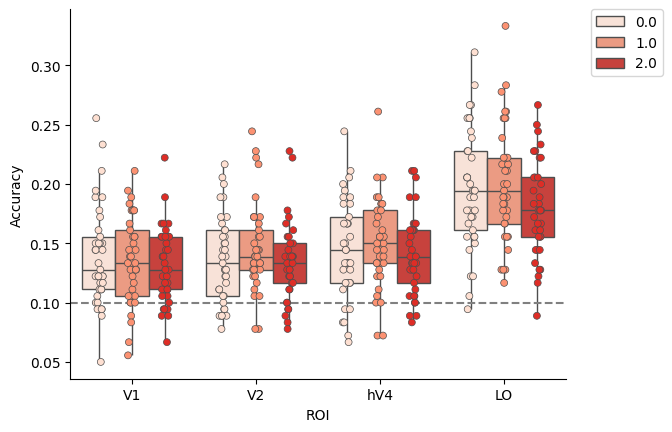

In [13]:
# Box plot

cols = ["#fee0d2", "#fc9272", "#de2d26"]
ax = sns.boxplot(data=all_sub_acc, x="roi", y="mean_acc",
                hue="cond", showcaps=False,
                flierprops={"marker":""},
                palette= cols)  
sns.stripplot(data=all_sub_acc, x="roi", y="mean_acc",
              hue="cond", dodge=True,palette=cols,linewidth=0.5,edgecolor='gray') 
handles, labels = ax.get_legend_handles_labels()
ax.set(xlabel='ROI', ylabel='Accuracy')
ax.legend(handles[0:3], labels[0:3], bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
fig = ax.get_figure()
sns.despine()
ax.axhline(0.1, color='gray', linestyle='--')

In [14]:
# one sample t-test: vs. chance level

import scipy.stats as stats
from statsmodels.stats.multitest import fdrcorrection

chance_level = 0.1
for roi in rois:
    p_values_roi = []
    for cond in [0.0, 1.0, 2.0]:
        data = np.array([*all_sub_acc['mean_acc'][(all_sub_acc['roi'] == roi) & (all_sub_acc['cond'] == cond)]])
        t_stat, p_value = stats.ttest_1samp(data, chance_level, alternative='greater')
        p_values_roi.append(p_value)

    rejected, corrected_p_values = fdrcorrection(p_values_roi, alpha=0.05)
    print(f'{roi} corrected p-values: {corrected_p_values}')

V1 corrected p-values: [1.33922893e-06 5.69930388e-07 5.69930388e-07]
V2 corrected p-values: [3.09594097e-07 8.64392609e-09 2.19710281e-07]
hV4 corrected p-values: [5.41486240e-08 1.92987798e-09 7.84587464e-09]
LO corrected p-values: [6.17572679e-14 1.89674414e-14 5.58760550e-14]


In [15]:
# pairwise t-test
import pingouin as pg

result = {}
for roi in rois: 
    result[roi] = pg.pairwise_tests(data=all_sub_acc[all_sub_acc["roi"]==roi], dv="mean_acc", between="cond", padjust="fdr_bh")

for roi in rois: 
    print(roi)
    display(result[roi])

V1


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,0.276379,72.0,two-sided,0.783049,0.783049,fdr_bh,0.248,0.063585
1,cond,0.0,2.0,False,True,0.876953,72.0,two-sided,0.383429,0.783049,fdr_bh,0.335,0.201756
2,cond,1.0,2.0,False,True,0.639313,72.0,two-sided,0.524648,0.783049,fdr_bh,0.287,0.147084


V2


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,-1.172027,72.0,two-sided,0.245050,0.367575,fdr_bh,0.434,-0.269642
1,cond,0.0,2.0,False,True,0.297053,72.0,two-sided,0.767282,0.767282,fdr_bh,0.25,0.068341
2,cond,1.0,2.0,False,True,1.526631,72.0,two-sided,0.131234,0.367575,fdr_bh,0.652,0.351224


hV4


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,-0.535069,72.0,two-sided,0.594251,0.635879,fdr_bh,0.272,-0.123101
1,cond,0.0,2.0,False,True,0.475488,72.0,two-sided,0.635879,0.635879,fdr_bh,0.265,0.109393
2,cond,1.0,2.0,False,True,1.096940,72.0,two-sided,0.276323,0.635879,fdr_bh,0.403,0.252367


LO


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,-0.465187,72.0,two-sided,0.643202,0.643202,fdr_bh,0.264,-0.107023
1,cond,0.0,2.0,False,True,1.587069,72.0,two-sided,0.116879,0.175319,fdr_bh,0.706,0.365129
2,cond,1.0,2.0,False,True,2.122707,72.0,two-sided,0.037218,0.111653,fdr_bh,1.626,0.488361


In [17]:
# ANOVA and post hoc


# ---------- shared formatting helpers ----------

def to_superscript(n):
    """Convert an integer to unicode superscript (e.g., -26 -> ⁻²⁶)."""
    sup = str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻')
    return str(n).translate(sup)


def fmt_p_num(x):
    """p-value to three decimals; scientific notation (n.nnn × 10⁻ⁿ)
    when p < .001. Blank for NaN."""
    if pd.isna(x):
        return ''
    if x >= .001:
        return f'{x:.3f}'.lstrip('0')
    mantissa, exp = f'{x:.3e}'.split('e')
    return f'{mantissa} × 10{to_superscript(int(exp))}'

def flag_p001(x):
    """Separate '< .001' indicator column."""
    return '' if pd.isna(x) else ('< .001' if x < .001 else '')


# ---------- ANOVA table ----------

def rm_anova_paper_table_combined(data, dv='mean_acc', subject='sub',
                                  within=('cond', 'roi'), labels=None):
    """pingouin two-way rm ANOVA -> publication-ready table.
    df/SS/MS are uncorrected (preserves additivity); ε and GG-corrected
    p-values are reported as additional columns."""
    aov = pg.rm_anova(data=data, dv=dv, within=list(within),
                      subject=subject, detailed=True)
    aov.columns = [c.replace('-', '_') for c in aov.columns]  # unify p-unc / p_unc

    if labels is None:
        labels = {'cond': 'Condition', 'roi': 'ROI',
                  'cond * roi': 'Condition × ROI'}

    # Subject and Total terms, computed directly from the raw data
    grand = data[dv].mean()
    ss_total = ((data[dv] - grand) ** 2).sum()
    df_total = len(data) - 1
    sub_means = data.groupby(subject)[dv].mean()
    n_cells = data.groupby(subject).size().iloc[0]  # cells per subject (12 here)
    ss_sub = (n_cells * (sub_means - grand) ** 2).sum()
    df_sub = sub_means.size - 1

    blank = dict(F=np.nan, p_unc=np.nan, eps=np.nan,
                 p_GG=np.nan, eta2G=np.nan)
    rows = [dict(Source='Subject', SS=ss_sub, df=df_sub,
                 MS=ss_sub / df_sub, **blank)]

    for _, r in aov.iterrows():
        lab = labels.get(r['Source'], r['Source'])
        ms_err = r['MS'] / r['F']      # recover error term from F = MS_effect / MS_error
        ss_err = ms_err * r['ddof2']
        rows.append(dict(Source=lab, SS=r['SS'], df=int(r['ddof1']),
                         MS=r['MS'], F=r['F'], p_unc=r['p_unc'],
                         eps=r['eps'], p_GG=r['p_GG_corr'],
                         eta2G=r['ng2']))
        rows.append(dict(Source=f'Error ({lab})', SS=ss_err,
                         df=int(r['ddof2']), MS=ms_err, **blank))

    rows.append(dict(Source='Total', SS=ss_total, df=df_total,
                     MS=np.nan, **blank))
    table = pd.DataFrame(rows)

    # Sanity check: both SS and df should sum to the Total row
    body = table[table['Source'] != 'Total']
    if not np.isclose(body['SS'].sum(), ss_total, rtol=1e-3):
        print(f"Warning: sum of SS ({body['SS'].sum():.4f}) "
              f"!= SS_total ({ss_total:.4f})")
    if body['df'].sum() != df_total:
        print(f"Warning: sum of df ({body['df'].sum():.0f}) "
              f"!= df_total ({df_total})")

    # Formatting for publication
    fmt = table.copy()
    fmt['SS'] = fmt['SS'].map(lambda x: f'{x:.3f}')
    fmt['df'] = fmt['df'].map(lambda x: f'{x:.0f}')
    fmt['MS'] = fmt['MS'].map(lambda x: '' if pd.isna(x) else f'{x:.4f}')
    fmt['F'] = fmt['F'].map(lambda x: '' if pd.isna(x) else f'{x:.2f}')
    fmt['p_unc'] = fmt['p_unc'].map(fmt_p_num)
    fmt['eps'] = fmt['eps'].map(lambda x: '' if pd.isna(x)
                                else f'{x:.3f}'.lstrip('0'))
    fmt['p_GG'] = fmt['p_GG'].map(fmt_p_num)
    fmt['eta2G'] = fmt['eta2G'].map(lambda x: '' if pd.isna(x)
                                    else f'{x:.3f}'.lstrip('0'))
    fmt = fmt.rename(columns={'p_unc': 'p', 'sig_unc': '',
                              'eps': 'ε', 'p_GG': 'p (GG)',
                              'sig_GG': ' ', 'eta2G': 'η²G'})
    # column order: p right before its flag column
    fmt = fmt[['Source', 'SS', 'df', 'MS', 'F', 'p',
               'ε', 'p (GG)', 'η²G']]
    return table, fmt


# ---------- Post hoc table ----------

def posthoc_paper_table(data, dv='mean_acc', subject='sub',
                        factor='cond', padjust='fdr_bh', labels=None):
    """Pairwise post hoc comparisons for one within-subject factor
    (paired t-tests with multiple-comparison correction),
    formatted as a publication-ready table."""
    # Collapse across the other factor: one value per subject x level
    agg = data.groupby([subject, factor])[dv].mean().reset_index()
    wide = agg.pivot(index=subject, columns=factor, values=dv)

    ph = pg.pairwise_tests(data=agg, dv=dv, within=factor,
                           subject=subject, padjust=padjust,
                           effsize='cohen')
    ph.columns = [c.replace('-', '_') for c in ph.columns] 
    # Mean difference (A - B) and paired 95% CI, per comparison
    stats_rows = []
    for _, r in ph.iterrows():
        d = wide[r['A']] - wide[r['B']]
        se = d.std(ddof=1) / np.sqrt(len(d))
        tcrit = stats.t.ppf(0.975, len(d) - 1)
        stats_rows.append((d.mean(), d.mean() - tcrit * se,
                           d.mean() + tcrit * se))
    ph[['mean_diff', 'ci_low', 'ci_high']] = pd.DataFrame(
        stats_rows, index=ph.index)

    # Optional relabeling (e.g., 0/1/2 -> condition names)
    if labels:
        ph['A'] = ph['A'].map(labels).fillna(ph['A'])
        ph['B'] = ph['B'].map(labels).fillna(ph['B'])

    fmt = pd.DataFrame({
        'Comparison': ph['A'].astype(str) + ' vs. ' + ph['B'].astype(str),
        'Mean diff.': ph['mean_diff'].map(lambda x: f'{x:.4f}'),
        '95% CI': ph.apply(lambda r: f"[{r['ci_low']:.4f}, {r['ci_high']:.4f}]",
                           axis=1),
        't': ph['T'].map(lambda x: f'{x:.2f}'),
        'df': ph['dof'].map(lambda x: f'{x:.0f}'),
        'p': ph['p_unc'].map(fmt_p_num),
        f'p ({padjust})': ph['p_corr'].map(fmt_p_num),
        "Cohen's d": ph['cohen'].map(lambda x: f'{x:.2f}'),
    })
    return ph, fmt

cond_labels = {0: 'warmth', 1: 'low heat', 2: 'high heat'}
raw_aov, aov_table = rm_anova_paper_table_combined(all_sub_acc, dv='mean_acc', subject='sub',
                                                   within=('cond', 'roi'),
                                                   labels = {'cond': 'Heat level', 'roi': 'ROI',
                                                             'cond * roi': 'Heat level × ROI'})
raw_cond, cond_table = posthoc_paper_table(all_sub_acc, dv='mean_acc', subject='sub',
                                           factor='cond', padjust='fdr_bh', 
                                           labels=cond_labels)
raw_roi, roi_table = posthoc_paper_table(all_sub_acc, dv='mean_acc', subject='sub',
                                         factor='roi', padjust='fdr_bh',
                                         labels=cond_labels)

/home/royoung/Programs/anaconda3/envs/NatPRF/lib/python3.11/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [18]:
print('Two-way repeated-measures ANOVA')
aov_table.to_csv('table_aov.csv', index=False)
aov_table

Two-way repeated-measures ANOVA


,Source,SS,df,MS,F,p,ε,p (GG),η²G
0,Subject,0.251,36,0.0070,,,,,
1,Heat level,0.011,2,0.0057,3.84,.026,.972,.027,.016
2,Error (Heat level),0.107,72,0.0015,,,,,
3,ROI,0.231,3,0.0769,75.58,2.041 × 10⁻²⁶,.837,1.695 × 10⁻²²,.252
4,Error (ROI),0.110,108,0.0010,,,,,
5,Heat level × ROI,0.005,6,0.0008,0.77,.597,.712,.557,.007
6,Error (Heat level × ROI),0.215,216,0.0010,,,,,
7,Total,0.929,443,,,,,,


In [19]:
print('Post hoc: cond')
cond_table.to_csv('table_heatLevel.csv', index=False)
cond_table

Post hoc: cond


,Comparison,Mean diff.,95% CI,t,df,p,p (fdr_bh),Cohen's d
0,warmth vs. low heat,-0.0045,"[-0.0143, 0.0053]",-0.93,36,.361,.361,-0.15
1,warmth vs. high heat,0.0078,"[-0.0007, 0.0163]",1.87,36,.070,.105,0.28
2,low heat vs. high heat,0.0123,"[0.0033, 0.0212]",2.78,36,.009,.026,0.44


In [20]:
print('Post hoc: roi')
roi_table.to_csv('table_ROI.csv', index=False)
roi_table

Post hoc: roi


,Comparison,Mean diff.,95% CI,t,df,p,p (fdr_bh),Cohen's d
0,LO vs. V1,0.0565,"[0.0477, 0.0652]",13.15,36,2.600 × 10⁻¹⁵,1.560 × 10⁻¹⁴,1.85
1,LO vs. V2,0.0531,"[0.0434, 0.0627]",11.12,36,3.368 × 10⁻¹³,1.010 × 10⁻¹²,1.76
2,LO vs. hV4,0.0463,"[0.0374, 0.0553]",10.51,36,1.629 × 10⁻¹²,3.259 × 10⁻¹²,1.42
3,V1 vs. V2,-0.0034,"[-0.0092, 0.0024]",-1.19,36,.244,.244,-0.14
4,V1 vs. hV4,-0.0101,"[-0.0193, -0.0009]",-2.23,36,.032,.048,-0.37
5,V2 vs. hV4,-0.0067,"[-0.0159, 0.0025]",-1.48,36,.148,.177,-0.25
